# 🧠 Custom Layers & Models in Keras

---

## 📋 Overview

In this notebook I build **custom Keras layers** from scratch by subclassing `tf.keras.layers.Layer`. Instead of relying on Keras's built-in `Dense` layer, I implement the full forward-pass logic myself — defining trainable weights, the matrix multiplication, and the activation function.

This is the foundation for anything non-standard in deep learning: custom attention heads, domain-specific signal transformations, exotic activations, or hardware-aware layers.

**What I build:**
- A `CustomDenseLayer` class with `build()` and `call()` methods
- A Sequential model using those layers
- Compile, train, evaluate the model
- Visualize the architecture
- Add Dropout regularization
- Experiment with different layer widths

---

## 🧩 Theory

### What is a Custom Keras Layer?

A Keras `Layer` is a building block that takes a tensor in, transforms it, and outputs a new tensor. The built-in `Dense` layer already does this, but by subclassing `Layer` I can define **any transformation I want** — with my own trainable parameters.

**Telecom analogy 📡:** Think of a custom layer like a custom DSP filter block in a signal chain. Each block has configurable parameters (e.g., filter taps = weights), a fixed processing rule (e.g., convolution = `call()`), and the parameters are initialized before processing starts (e.g., `build()`). Keras trains those filter taps end-to-end via backpropagation.

### The Three Methods

| Method | When it runs | What it does |
|---|---|---|
| `__init__` | At object creation | Stores hyperparameters (number of units, etc.) |
| `build(input_shape)` | First time a tensor flows through | Allocates trainable weights based on actual input shape |
| `call(inputs)` | Every forward pass | Computes the layer's output |

### The Math

A dense layer computes:

$$\mathbf{y} = f(\mathbf{x} \cdot \mathbf{W} + \mathbf{b})$$

Where:
- $\mathbf{x} \in \mathbb{R}^{n \times d_{in}}$ — input batch (n samples, $d_{in}$ features)
- $\mathbf{W} \in \mathbb{R}^{d_{in} \times d_{out}}$ — weight matrix
- $\mathbf{b} \in \mathbb{R}^{d_{out}}$ — bias vector
- $f$ — activation function (here: ReLU)
- $\mathbf{y} \in \mathbb{R}^{n \times d_{out}}$ — output batch

For the **ReLU activation**:

$$\text{ReLU}(z) = \max(0, z)$$

It clips negative values to zero and passes positives through — like a half-wave rectifier in RF hardware.

### Weight Initialization

Before training, weights must be initialized to break symmetry. If all weights started at zero, every neuron would compute the same gradient and learn the same thing — the network would never differentiate.

I use:
- `random_normal` for weights $\mathbf{W}$ — small random values break symmetry
- `zeros` for biases $\mathbf{b}$ — safe to start at zero

### Softmax for Multi-Class Output

For a 10-class classification problem the output layer uses Softmax:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Where $K$ is the number of classes. This converts raw scores into probabilities that sum to 1 — like normalizing signal power across frequency bands so the total sums to 100%.

---

## ⚙️ Part 1 — Setup

I install the required libraries and import the core components. `tensorflow.keras.layers.Layer` is the base class I'll subclass for my custom layer.

In [3]:
!pip install tensorflow==2.16.2 --quiet
!pip install pydot graphviz --quiet

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import Sequential

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.2


---

## 🏗️ Part 2 — Building a Custom Dense Layer

I subclass `tf.keras.layers.Layer` to create my own fully-connected layer. The key insight: Keras separates **parameter allocation** (`build`) from **computation** (`call`). This lazy initialization means the layer doesn't need to know the input shape until actual data flows through — a pattern common in modular RF/DSP pipelines where block inputs are dynamically wired.

**What `add_weight()` does:** it registers a tensor as a trainable parameter so Keras tracks it during backpropagation. It's like declaring a register as writable in hardware — Keras then knows to compute gradients for it.

In [5]:
class CustomDenseLayer(Layer):
    """
    A manually implemented fully-connected (dense) layer.
    
    Computes: y = ReLU(x @ W + b)
    - W shape: (input_dim, units)  — the weight matrix
    - b shape: (units,)            — the bias vector
    """

    def __init__(self, units=32):
        """Store hyperparameters only — no weights yet."""
        super(CustomDenseLayer, self).__init__()
        self.units = units  # number of output neurons

    def build(self, input_shape):
        """
        Allocate trainable weights once we know the input shape.
        Called automatically on first forward pass.
        
        input_shape[-1] gives the number of input features.
        """
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',  # small random values — breaks symmetry
            trainable=True,
            name='kernel'
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',  # biases can safely start at zero
            trainable=True,
            name='bias'
        )

    def call(self, inputs):
        """
        Forward pass: y = ReLU(x @ W + b)
        This runs on every batch during training and inference.
        """
        return tf.nn.relu(tf.matmul(inputs, self.w) + self.b)


# Quick sanity check — instantiate the layer
test_layer = CustomDenseLayer(units=32)
print(f"CustomDenseLayer created with {test_layer.units} units")
print("Weights not yet allocated (build hasn't been called)")

CustomDenseLayer created with 32 units
Weights not yet allocated (build hasn't been called)


---

## 🔢 Part 3 — Integrating Custom Layers into a Sequential Model

I stack two `CustomDenseLayer` blocks and top them with a **Softmax** output layer. This architecture maps 20 input features → 128 hidden units → 10 class logits → 10 class probabilities.

```
Input (20 features)
    ↓
[CustomDenseLayer 128]  →  ReLU(x·W₁ + b₁)   shape: (batch, 128)
    ↓
[CustomDenseLayer 10]   →  ReLU(x·W₂ + b₂)   shape: (batch, 10)
    ↓
[Softmax]               →  probabilities        shape: (batch, 10)
```

Note: `Softmax` is added as a separate layer — this matches the pattern where the final custom layer outputs **logits** (raw scores), and Softmax converts them to **probabilities**. Keeping them separate gives me flexibility to inspect logits directly if needed.

In [6]:
from tensorflow.keras.layers import Softmax

# Build the model: two custom layers + softmax output
model = Sequential([
    CustomDenseLayer(128),   # hidden layer — 128 units, ReLU activation
    CustomDenseLayer(10),    # pre-output layer — 10 units (one per class), ReLU
    Softmax()                # convert logits → probabilities (sums to 1)
])

print("Model created — layers:", [layer.__class__.__name__ for layer in model.layers])

Model created — layers: ['CustomDenseLayer', 'CustomDenseLayer', 'Softmax']


---

## ⚙️ Part 4 — Compile & Inspect the Model

I compile with `categorical_crossentropy` loss — the standard choice when labels are one-hot encoded and the output is a Softmax probability distribution.

**Loss function:**

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

Where $y_{ik}$ is the true label (0 or 1, one-hot) and $\hat{y}_{ik}$ is the predicted probability for class $k$ on sample $i$.

Note: `model.summary()` shows `(None, None)` for input/output shapes before `build()` is called — because Keras doesn't know the input shape yet. After calling `model.build()`, the weight shapes become concrete.

In [7]:
# Compile — Adam optimizer, categorical cross-entropy for 10-class problem
model.compile(optimizer='adam', loss='categorical_crossentropy')

print("Model summary before building (shapes unknown):")
model.summary()

# Build with explicit input shape: (batch_size=1000, features=20)
model.build((1000, 20))

print("\nModel summary after building (shapes resolved):")
model.summary()

Model summary before building (shapes unknown):


2026-06-19 22:39:41.101925: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-06-19 22:39:41.101948: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-19 22:39:41.101955: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-19 22:39:41.101971: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-19 22:39:41.101989: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_dense_layer_1            │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer_2            │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_dense_layer_1            │ (1000, 128)            │         2,688 │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer_2            │ (1000, 10)             │         1,290 │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (1000, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,978 (15.54 KB)

 Trainable params: 3,978 (15.54 KB)

 Non-trainable params: 0 (0.00 B)

---

## 📥 Part 5 — Training the Model

I train on randomly generated data — 1000 samples, 20 features each, 10 classes. In a real project this would be replaced with actual data (e.g., RF signal features, network KPIs, sensor readings).

**Key step — one-hot encoding:** labels must be converted from integer class indices `[0, 9]` to binary vectors `[0,0,1,0,...,0]` because categorical cross-entropy expects one-hot format.

For example, class 3 out of 10 becomes:

$$\mathbf{y} = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]$$

Each training epoch processes all 1000 samples in mini-batches of 32, computing gradients and updating weights via Adam.

In [8]:
# Generate synthetic training data
x_train = np.random.random((1000, 20))           # 1000 samples, 20 features
y_train = np.random.randint(10, size=(1000, 1))   # integer labels 0–9

# Convert integer labels → one-hot encoded vectors
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)

print(f"Training data shape: x={x_train.shape}, y={y_train.shape}")
print(f"Example label (first sample): {y_train[0]}")

# Train for 10 epochs with batch size 32
history = model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)

Training data shape: x=(1000, 20), y=(1000, 10)
Example label (first sample): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Epoch 1/10


2026-06-19 22:39:41.380513: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.3039
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2994
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2980
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2971
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2944
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2932
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2913
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2886
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2895


---

## 📊 Part 6 — Evaluating the Model

I evaluate on a held-out test set of 200 samples. With random data and 10 classes, chance-level accuracy is ~10% — this is expected. The goal here is verifying the pipeline works end-to-end, not achieving real performance.

In [9]:
# Generate synthetic test data
x_test = np.random.random((200, 20))
y_test = np.random.randint(10, size=(200, 1))
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"Test data shape: x={x_test.shape}, y={y_test.shape}")

# Evaluate — returns loss (and any compiled metrics)
loss = model.evaluate(x_test, y_test, verbose=1)
print(f"\n🎯 Test loss: {loss:.4f}")
print("(Random baseline expected — data is synthetic)")

Test data shape: x=(200, 20), y=(200, 10)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3023 

🎯 Test loss: 2.3023
(Random baseline expected — data is synthetic)


---

## 🖼️ Part 7 — Visualizing Model Architecture

`plot_model` from `tensorflow.keras.utils` generates a diagram of the model architecture — showing each layer, its output shape, and how layers connect. I save it as a PNG and display it inline.

This is useful for:
- Debugging unexpected layer connections
- Including in reports or portfolio notebooks
- Communicating architecture to stakeholders (like an RF block diagram)

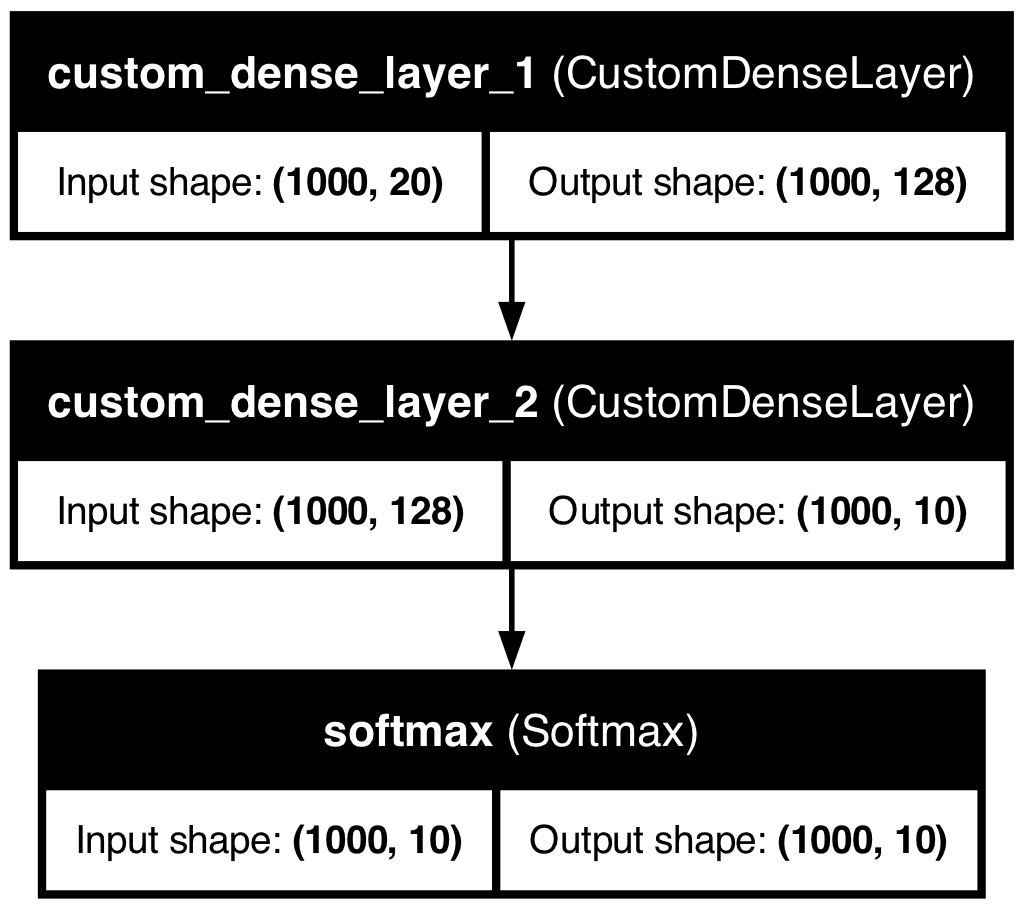

In [16]:
from tensorflow.keras.utils import plot_model

# Visualize the model architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

---

## 🔄 Part 8 — Adding Dropout Regularization

**Dropout** randomly zeroes out a fraction of neurons during each training step. This prevents the network from co-adapting — no single neuron can rely on any specific upstream neuron always being active.

**The math:** for a dropout rate $p$, each neuron output $h_i$ becomes:

$$\tilde{h}_i = h_i \cdot \text{Bernoulli}(1-p)$$

During **inference**, dropout is disabled and all neurons are active — activations are scaled by $(1-p)$ to compensate.

**RF analogy 📡:** Dropout is like simulated path fading in a link-budget test. By randomly dropping sub-channels during training, the network learns to be robust to any individual path going down — like a beam-formed array that doesn't depend on any single antenna element.

Here I add `Dropout(0.5)` between the custom layers — meaning 50% of neurons are randomly silenced per batch.

In [18]:
from tensorflow.keras.layers import Dropout

# Rebuild model with Dropout regularization between custom layers
model_with_dropout = Sequential([
    CustomDenseLayer(64),    # hidden layer
    Dropout(0.5),            # drop 50% of neurons randomly during training
    CustomDenseLayer(10),    # pre-output layer
    Softmax()                # output probabilities
])

# Compile and train
model_with_dropout.compile(optimizer='adam', loss='categorical_crossentropy')

print("Training model with Dropout:")
history_dropout = model_with_dropout.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

print("\n✅ Training complete — observe how dropout affects convergence speed")

Training model with Dropout:
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3020
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2982
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2967
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2963
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2969
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2935
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2951
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2926
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2928
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2901

✅ Training complete — observe how dropout affects convergence speed


---

## ➕ Part 9 — Experimenting with Layer Width

I redefine the custom layer with a default of 128 units and rebuild the model. More units = more parameters = higher capacity — but also higher risk of overfitting and longer training time.

**Parameter count comparison:**

| Configuration | Layer 1 params | Layer 2 params | Total |
|---|---|---|---|
| 64 units (baseline) | 20×64 + 64 = 1,344 | 64×10 + 10 = 650 | 1,994 |
| 128 units (expanded) | 20×128 + 128 = 2,688 | 128×10 + 10 = 1,290 | 3,978 |

Doubling the hidden layer size doubles the parameter count — a non-trivial cost on real datasets, but negligible here on toy data.

In [19]:
# Redefine with 128 units as default
class CustomDenseLayer128(Layer):
    """Custom dense layer — default 128 units."""

    def __init__(self, units=128):
        super(CustomDenseLayer128, self).__init__()
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True,
            name='kernel'
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )

    def call(self, inputs):
        return tf.nn.relu(tf.matmul(inputs, self.w) + self.b)


# Rebuild model with wider hidden layer
model_wide = Sequential([
    CustomDenseLayer128(128),   # 128 units in hidden layer
    CustomDenseLayer128(10),    # 10 output units
    Softmax()
])

model_wide.compile(optimizer='adam', loss='categorical_crossentropy')
model_wide.build((1000, 20))

print("Wide model summary:")
model_wide.summary()

print("\nTraining wide model:")
history_wide = model_wide.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

Wide model summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_dense_layer128_2         │ (1000, 128)            │         2,688 │
│ (CustomDenseLayer128)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer128_3         │ (1000, 10)             │         1,290 │
│ (CustomDenseLayer128)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_6 (Softmax)             │ (1000, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,978 (15.54 KB)

 Trainable params: 3,978 (15.54 KB)

 Non-trainable params: 0 (0.00 B)


Training wide model:
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3022
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2965
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2947
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2925
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2905
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2878
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2861
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2840
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2818
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2778


---

## 📊 Summary

### What I built

| Step | What I did | Key concept |
|---|---|---|
| 🏗️ Custom layer | Subclassed `tf.keras.layers.Layer` | `build()` + `call()` pattern |
| 🔢 Weight init | Used `add_weight()` to register trainable params | `random_normal` breaks symmetry; `zeros` for bias |
| ➕ Forward pass | Implemented $\text{ReLU}(x \cdot W + b)$ manually | `tf.matmul` + `tf.nn.relu` |
| 🏗️ Model stack | Combined custom layers in `Sequential` | Modular, reusable architecture |
| 📤 Softmax output | Added `Softmax()` layer for 10-class probabilities | Converts logits → probability distribution |
| ⚙️ Compile & train | Used Adam + categorical cross-entropy | Standard setup for multi-class |
| 🖼️ Visualize | `plot_model()` for architecture diagram | Useful for debugging and documentation |
| 🔄 Dropout | Added `Dropout(0.5)` for regularization | Prevents co-adaptation of neurons |
| ➕ Width experiment | Doubled units to 128 — ~2× parameter count | Capacity vs. overfitting trade-off |

### Key equations

| Formula | Description |
|---|---|
| $\mathbf{y} = \text{ReLU}(\mathbf{x} \cdot \mathbf{W} + \mathbf{b})$ | Dense layer forward pass |
| $\text{ReLU}(z) = \max(0, z)$ | ReLU activation |
| $\text{Softmax}(z_i) = e^{z_i} / \sum_j e^{z_j}$ | Output probabilities |
| $\mathcal{L} = -\sum_{i,k} y_{ik} \log(\hat{y}_{ik})$ | Categorical cross-entropy loss |
| $\tilde{h}_i = h_i \cdot \text{Bernoulli}(1-p)$ | Dropout mask |

### Telecom connections 📡

| Deep learning concept | RF / Telecom analogy |
|---|---|
| Custom layer (`build` + `call`) | DSP filter block with configurable taps |
| Weight initialization | Seed values for PRBS-based signal generators |
| ReLU activation | Half-wave rectifier in RF front-end |
| Softmax output | Normalized power distribution across frequency bands |
| Dropout regularization | Simulated path fading in link-budget test |
| Layer width (units) | Number of subcarriers in OFDM — more = more capacity, but more overhead |

---

## 🧪 Sandbox

Free experimentation space. Try things without worrying about the main pipeline.

In [13]:
# SANDBOX — Idea 1: Custom layer with a different activation
# Try replacing ReLU with tanh and observe how training loss changes

class CustomDenseTanh(Layer):
    def __init__(self, units=32):
        super().__init__()
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',  # Xavier init — better for tanh
            trainable=True
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return tf.nn.tanh(tf.matmul(inputs, self.w) + self.b)


model_tanh = Sequential([
    CustomDenseTanh(64),
    CustomDenseTanh(10),
    Softmax()
])
model_tanh.compile(optimizer='adam', loss='categorical_crossentropy')
history_tanh = model_tanh.fit(x_train, y_train, epochs=5, batch_size=32, verbose=1)

print("\nCompare final loss — ReLU vs Tanh:")
print(f"  ReLU model:  {history.history['loss'][-1]:.4f}")
print(f"  Tanh model:  {history_tanh.history['loss'][-1]:.4f}")

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3385
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3086
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.3030
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2945
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2872

Compare final loss — ReLU vs Tanh:
  ReLU model:  2.2895
  Tanh model:  2.2872


In [14]:
# SANDBOX — Idea 2: Inspect the actual weight values after training
# Useful for debugging — are weights in a reasonable range?

for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        w, b = weights
        print(f"Layer: {layer.name}")
        print(f"  W shape: {w.shape} | mean: {w.mean():.4f} | std: {w.std():.4f}")
        print(f"  b shape: {b.shape} | mean: {b.mean():.4f}")
        print()

Layer: custom_dense_layer_1
  W shape: (20, 128) | mean: 0.0026 | std: 0.0570
  b shape: (128,) | mean: 0.0020

Layer: custom_dense_layer_2
  W shape: (128, 10) | mean: -0.0077 | std: 0.0589
  b shape: (10,) | mean: -0.0045



In [15]:
# SANDBOX — Idea 3: Real-world extension idea
# Custom layer for telecom signal features:
# - Apply a learnable linear transform to I/Q baseband samples
# - This is the deep-learning equivalent of matched filtering

class IQTransformLayer(Layer):
    """
    A custom layer for I/Q signal processing.
    Treats pairs of features as (In-phase, Quadrature) components.
    Applies a learnable complex-valued linear transform.
    
    Input: (batch, 2*N) — interleaved I/Q samples
    Output: (batch, units) — transformed feature representation
    """
    def __init__(self, units=32):
        super().__init__()
        self.units = units

    def build(self, input_shape):
        self.w_i = self.add_weight(shape=(input_shape[-1], self.units),
                                    initializer='glorot_uniform', trainable=True, name='w_inphase')
        self.w_q = self.add_weight(shape=(input_shape[-1], self.units),
                                    initializer='glorot_uniform', trainable=True, name='w_quadrature')
        self.b   = self.add_weight(shape=(self.units,),
                                    initializer='zeros', trainable=True, name='bias')

    def call(self, inputs):
        # Combine I and Q pathways — analogous to complex channel estimation
        return tf.nn.relu(tf.matmul(inputs, self.w_i) + tf.matmul(inputs, self.w_q) + self.b)


# Test with 20 features (treated as 10 complex I/Q pairs)
iq_layer = IQTransformLayer(units=16)
test_input = tf.random.normal((8, 20))  # batch of 8, 20 features
output = iq_layer(test_input)
print(f"IQ Transform Layer — input: {test_input.shape} → output: {output.shape}")
print("✅ Custom telecom-inspired layer working")

IQ Transform Layer — input: (8, 20) → output: (8, 16)
✅ Custom telecom-inspired layer working
